In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(140,170)

159

In [4]:
data=[]
for i in range(50):
    # 여자 데이터(키와 몸무게) 추가
    data.append([random.randint(40,70),random.randint(140,170)])
    # 남자 데이터(키와 몸무게) 추가
    data.append([random.randint(60,95),random.randint(160,195)])

In [5]:
print('여자 몸무게(x축):',[female[0] for female in data[::2]])
print('여자 키(y축):',[female[1] for female in data[::2]])    

print('남자 몸무게(x축):',[male[0] for male in data[1::2]])
print('남자 키(y축):',[male[1] for male in data[1::2]])                     

여자 몸무게(x축): [56, 70, 40, 60, 54, 61, 44, 42, 44, 69, 42, 50, 50, 66, 63, 63, 63, 57, 52, 66, 70, 63, 48, 41, 66, 46, 48, 66, 67, 68, 70, 70, 44, 53, 54, 40, 64, 55, 43, 62, 54, 67, 51, 58, 64, 54, 47, 70, 40, 66]
여자 키(y축): [170, 151, 144, 156, 157, 154, 149, 142, 153, 150, 167, 164, 151, 152, 153, 166, 152, 167, 168, 162, 153, 143, 162, 159, 155, 148, 163, 157, 142, 166, 142, 170, 153, 170, 147, 165, 150, 142, 154, 140, 150, 141, 144, 151, 142, 162, 167, 161, 141, 167]
남자 몸무게(x축): [75, 87, 83, 88, 65, 73, 64, 81, 79, 85, 73, 84, 93, 81, 92, 72, 93, 62, 68, 77, 82, 65, 80, 93, 91, 68, 79, 77, 78, 85, 68, 62, 73, 60, 69, 92, 80, 69, 92, 86, 77, 88, 95, 85, 64, 82, 95, 66, 80, 77]
남자 키(y축): [172, 161, 176, 175, 174, 187, 183, 165, 188, 194, 175, 195, 161, 164, 193, 163, 185, 173, 194, 193, 166, 186, 188, 188, 175, 164, 168, 181, 178, 172, 194, 174, 175, 173, 170, 170, 181, 173, 166, 179, 165, 174, 185, 189, 176, 180, 160, 182, 160, 169]


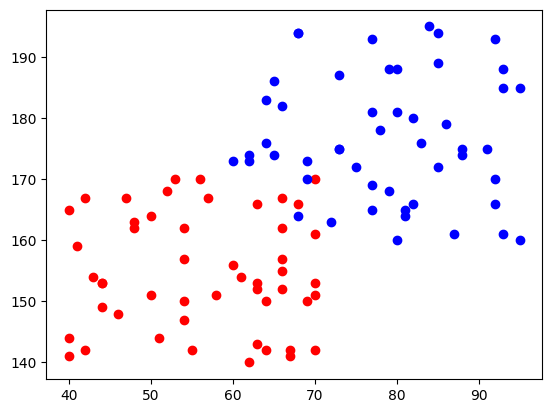

In [7]:
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]],'o',color='b')
plt.show()

# 2. 군집화 로직

In [8]:
# 초기 랜덤 지점 2개
random_points=[
    [random.randint(40,90),random.randint(140,195)],
    [random.randint(40,90),random.randint(140,195)]
]
random_points[0],random_points[1]

([61, 188], [47, 176])

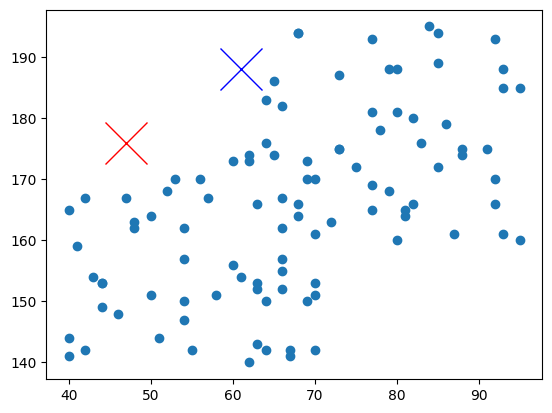

In [9]:
plt.plot([d[0] for d in data],
        [d[1] for d in data],'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30,color='b')# 기준점 0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30,color='r')# 기준점 1

In [10]:
# 두점거리를 return하는 함수 점은[50,150]
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
print(dist([3,4],[0,0]))
print(dist([5,7],[-1,-1]))

5.0
10.0


In [19]:
 # random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group0.append(d)
    else:
        group1.append(d)
len(group0),len(group1)

(50, 50)

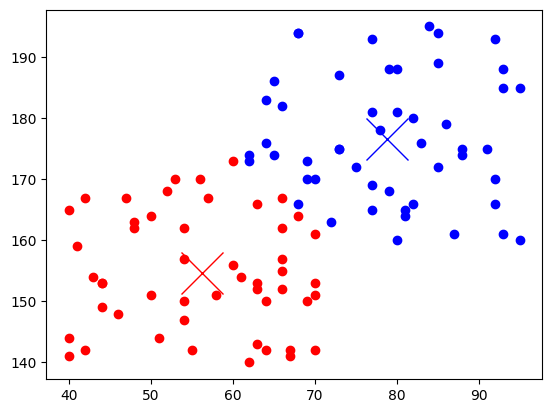

In [20]:
#group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

In [21]:
# group0과 group1 중심점으로 기준점을 이용
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX,group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX,group1_meanY]
random_points

[[78.86, 176.62], [56.22, 154.72]]

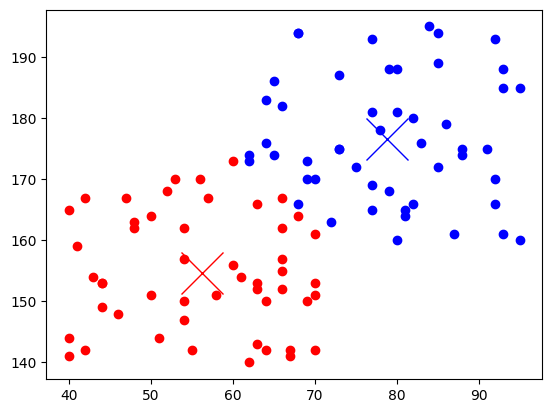

In [22]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

# 3.군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정 - 출력및 시각화
- for문
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤 포인트로 업데이트
    * 랜덤 포인트 출력 및 시각화

초기지점: [[56, 155], [78, 183]]
1 번째 points: [[60.945945945945944, 150.32432432432432], [71.41269841269842, 174.68253968253967]]
2 번째 points: [[55.2, 153.44444444444446], [77.63636363636364, 175.6727272727273]]
3 번째 points: [[55.9375, 154.08333333333334], [78.25, 176.3653846153846]]
4 번째 points: [[56.02040816326531, 154.46938775510205], [78.6078431372549, 176.4313725490196]]
5 번째 points: [[56.22, 154.72], [78.86, 176.62]]
6 번째 points: [[56.22, 154.72], [78.86, 176.62]]
7 번째 points: [[56.22, 154.72], [78.86, 176.62]]
8 번째 points: [[56.22, 154.72], [78.86, 176.62]]
9 번째 points: [[56.22, 154.72], [78.86, 176.62]]
10 번째 points: [[56.22, 154.72], [78.86, 176.62]]


(145.0, 195.0)

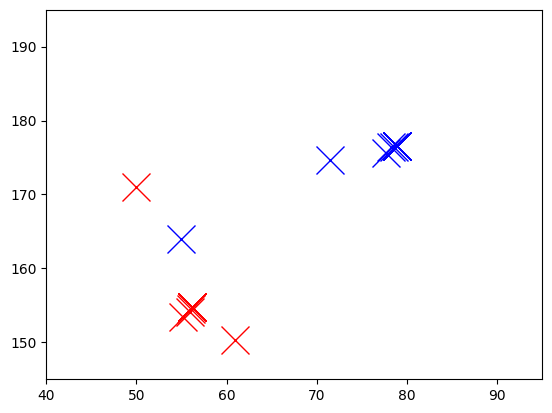

In [35]:
points = [
    [random.randint(40,95),random.randint(140,195)],
    [random.randint(40,95),random.randint(140,195)],
]
print('초기지점:',point)
plt.plot(points[0][0],points[0][1],'x',color='r',markersize=20)
plt.plot(points[1][0],points[1][1],'x',color='b',markersize=20)
for i in range(1,11):
    #points 두지점을 기준으로 group0과 group1나누기
    group0=[]
    group1=[]
    for info in data:
        if dist(point[0],info)<dist(points[1],info):
            group0.append(info)
        else:
            group1.append(info)
    #group0의 중간점, group1의 중간점으로 points 업데이트
    group0_meanX = np.mean([g[0] for g in group0])
    group0_meanY = np.mean([g[1] for g in group0])
    points[0] = [group0_meanX,group0_meanY]
    
    group1_meanX = np.mean([g[0] for g in group1])
    group1_meanY = np.mean([g[1] for g in group1])
    points[1] = [group1_meanX,group1_meanY]
    #업데이트된 points 출력 및 시각화
    print(i,'번째 points:',points)
    plt.plot(points[0][0],points[0][1],'x',color='r',markersize=20)
    plt.plot(points[1][0],points[1][1],'x',color='b',markersize=20)
plt.xlim([40,95])
plt.ylim([145,195])

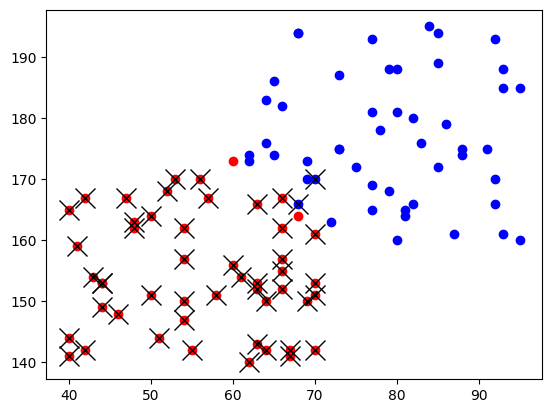

In [38]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o',color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o',color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'x',color='k',markersize=15)

# 4.api(sklearn)를 이용한 군집화
- sklearn : 머신러닝 패키지
    * 예측/ 군집모델 : 회귀분석, 분류분석,군집분석 - fit(학습),predict(예측,분류)
    * 변환모델 : 전처리할떄 사용 ex.인코딩,스케일 조정...-fit(학습),transform(변환함수),fit_transform(학변)

In [ ]:
# import os
# os.environ['OMP_NUN_THREADS'] = '1'
# import warnings
# warnings.filterwarnings(action='ignore') # 경고 무시

In [41]:
from sklearn.cluster import KMeans
data = np.array(data) #원칙적으로 머신러닝 모델엔 넘파이 배열로 학습
model = KMeans(n_clusters=2, # 2개 그룹으로 군집화
              init='random', # 초기포인트를 random하게 
              n_init=10,     # 10번 실행
              random_state=7)# 일관적인 모델을 생성하기 위한 seed값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [42]:
# 두그룹의 기준점:[56.22, 154.72], [78.86, 176.62]
model.cluster_centers_

array([[ 78.05660377, 176.13207547],
       [ 55.68085106, 153.87234043]])

In [43]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0])

In [45]:
group1=data[model.labels_==1]
group0=data[model.labels_==0]

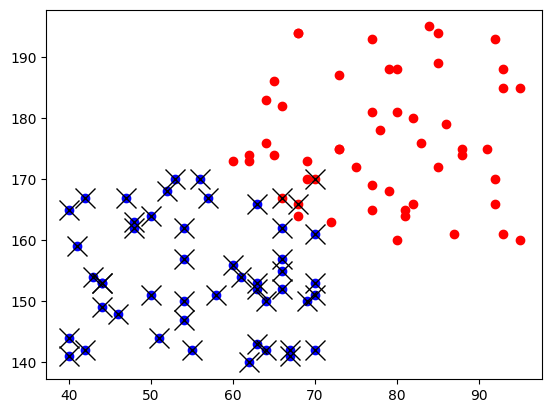

In [46]:
plt.plot([g[0] for g in group0],
         [g[1] for g in group0], 'o',color='r')
plt.plot([g[0] for g in group1],
         [g[1] for g in group1], 'o',color='b')
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'x',color='k',markersize=15)
plt.show()